In [1]:
!pip install git+https://github.com/m4rz910/NYISOToolkit#egg=nyisotoolkit

  Cloning https://github.com/m4rz910/NYISOToolkit to /tmp/pip-install-gii87xda/nyisotoolkit_1562558ec7894388bdc5808673f8fc8c
  Running command git clone --filter=blob:none --quiet https://github.com/m4rz910/NYISOToolkit /tmp/pip-install-gii87xda/nyisotoolkit_1562558ec7894388bdc5808673f8fc8c
  Resolved https://github.com/m4rz910/NYISOToolkit to commit 7759c31370a65ce058a780e50d40cd87ce07e239
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.0 MB/s eta 0:00:00
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wh

In [1]:
import pandas as pd
from nyisotoolkit import NYISOData

years = ['2020', '2021', '2022', '2023', '2024', '2025']


dfs = []
for y in years:
    df = NYISOData(dataset='load_h', year=y).df
    dfs.append(df)

load_df = pd.concat(dfs)

load_df = load_df.tz_convert("US/Eastern")

print(load_df.head())
print(load_df.tail())


Name                       CAPITL  CENTRL  DUNWOD  GENESE  HUD VL  LONGIL  \
Time Stamp                                                                  
2020-01-01 00:00:00-05:00  1180.6  1630.5   553.7   982.7   941.3  1986.3   
2020-01-01 01:00:00-05:00  1135.7  1575.6   535.4   947.6   901.9  1891.3   
2020-01-01 02:00:00-05:00  1107.1  1549.5   517.1   924.2   876.9  1815.5   
2020-01-01 03:00:00-05:00  1095.1  1527.5   505.4   909.0   856.0  1767.3   
2020-01-01 04:00:00-05:00  1099.7  1548.3   501.2   912.5   858.4  1762.0   

Name                       MHK VL  MILLWD  N.Y.C.  NORTH    WEST     NYCA  
Time Stamp                                                                 
2020-01-01 00:00:00-05:00   795.5   303.8  4897.1  604.5  1540.9  15416.9  
2020-01-01 01:00:00-05:00   761.8   292.3  4763.3  600.8  1485.7  14891.4  
2020-01-01 02:00:00-05:00   748.6   279.9  4622.3  596.7  1467.9  14505.7  
2020-01-01 03:00:00-05:00   742.4   274.5  4510.8  595.7  1442.4  14226.1  
2020

In [2]:
df = load_df[['N.Y.C.']].rename(columns={'N.Y.C.':'load_mw'})
df

Name,load_mw
Time Stamp,
2020-01-01 00:00:00-05:00,4897.1000
2020-01-01 01:00:00-05:00,4763.3000
2020-01-01 02:00:00-05:00,4622.3000
2020-01-01 03:00:00-05:00,4510.8000
2020-01-01 04:00:00-05:00,4456.4000
...,...
2025-09-27 03:00:00-04:00,4975.4589
2025-09-27 04:00:00-04:00,4886.3708
2025-09-27 05:00:00-04:00,4898.5669


In [3]:
!pip install meteostat
from datetime import datetime
from meteostat import Hourly, Stations

start = datetime(2020,1,1,0,0)
end   = datetime(2025,12,31,23,59)

# Find nearest station to NYC
stations = Stations()
station = stations.region('US','NY').fetch(10)  # top 10 NY stations
# JFK Airport (KJFK) is best choice
station_id = '72503'  # JFK NOAA ID
weather = Hourly(station_id, start, end)
weather_df = weather.fetch()

# Keep key weather features
weather_df = weather_df[['temp','rhum','prcp']]  # °C, %, mm
weather_df = weather_df.rename(columns={'temp':'temperature','rhum':'humidity','prcp':'precipitation'})

print("Weather data:", weather_df.shape,"\n", weather_df.head)

Weather data: (50554, 3) 
 <bound method NDFrame.head of                      temperature  humidity  precipitation
time                                                     
2020-01-01 00:00:00          6.7      70.0           <NA>
2020-01-01 01:00:00          7.2      68.0            0.0
2020-01-01 02:00:00          6.7      68.0            0.3
2020-01-01 03:00:00          6.1      65.0           <NA>
2020-01-01 04:00:00          5.6      67.0           <NA>
...                          ...       ...            ...
2025-10-07 05:00:00         17.6      62.0           <NA>
2025-10-07 06:00:00         17.3      63.0           <NA>
2025-10-07 07:00:00         17.0      64.0           <NA>
2025-10-07 08:00:00         16.6      66.0           <NA>
2025-10-07 09:00:00         16.5      66.0           <NA>

[50554 rows x 3 columns]>


In [4]:
weather_df = weather_df.drop(columns=['precipitation'])

In [5]:
weather_df.index = weather_df.index.tz_localize(None)

weather_df.index = weather_df.index.tz_localize(
    'America/New_York',
    ambiguous='NaT',      # mark ambiguous fall-back times as NaT
    nonexistent='shift_forward'  # handle spring-forward missing hour
)

weather_df = weather_df.dropna()

df = df.merge(weather_df, left_index=True, right_index=True, how='left')
df

,load_mw,temperature,humidity
Time Stamp,,,
2020-01-01 05:00:00+00:00,4897.1000,6.7,70.0
2020-01-01 06:00:00+00:00,4763.3000,7.2,68.0
2020-01-01 07:00:00+00:00,4622.3000,6.7,68.0
2020-01-01 08:00:00+00:00,4510.8000,6.1,65.0
2020-01-01 09:00:00+00:00,4456.4000,5.6,67.0
...,...,...,...
2025-09-27 07:00:00+00:00,4975.4589,23.3,53.0
2025-09-27 08:00:00+00:00,4886.3708,22.8,55.0
2025-09-27 09:00:00+00:00,4898.5669,21.7,61.0


In [6]:
from pandas.tseries.holiday import USFederalHolidayCalendar
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df.index.min(), end=df.index.max())
df['is_holiday'] = df.index.normalize().isin(holidays).astype(int)

print(df.head())

                           load_mw  temperature  humidity  is_holiday
Time Stamp                                                           
2020-01-01 05:00:00+00:00   4897.1          6.7      70.0           0
2020-01-01 06:00:00+00:00   4763.3          7.2      68.0           0
2020-01-01 07:00:00+00:00   4622.3          6.7      68.0           0
2020-01-01 08:00:00+00:00   4510.8          6.1      65.0           0
2020-01-01 09:00:00+00:00   4456.4          5.6      67.0           0


In [7]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

for lag in [1, 24, 168]:
    df[f'load_lag_{lag}'] = df['load_mw'].shift(lag)

df = df.dropna()
df


,load_mw,temperature,humidity,is_holiday,hour,day_of_week,month,is_weekend,load_lag_1,load_lag_24,load_lag_168
Time Stamp,,,,,,,,,,,
2020-01-08 05:00:00+00:00,4819.3000,4.4,55.0,0,5,2,1,0,5121.6000,4806.9000,4897.1000
2020-01-08 06:00:00+00:00,4636.7000,2.8,70.0,0,6,2,1,0,4819.3000,4608.5000,4763.3000
2020-01-08 07:00:00+00:00,4524.6000,2.8,76.0,0,7,2,1,0,4636.7000,4493.3000,4622.3000
2020-01-08 08:00:00+00:00,4489.6000,1.7,85.0,0,8,2,1,0,4524.6000,4445.6000,4510.8000
2020-01-08 09:00:00+00:00,4539.8000,2.2,85.0,0,9,2,1,0,4489.6000,4492.9000,4456.4000
...,...,...,...,...,...,...,...,...,...,...,...
2025-09-27 07:00:00+00:00,4975.4589,23.3,53.0,0,7,5,9,1,5127.0894,5034.2726,4663.2554
2025-09-27 08:00:00+00:00,4886.3708,22.8,55.0,0,8,5,9,1,4975.4589,5022.4247,4551.3856
2025-09-27 09:00:00+00:00,4898.5669,21.7,61.0,0,9,5,9,1,4886.3708,5207.6110,4521.5588


In [8]:
train_df = df[df.index < '2025-01-01']
test_df = df[df.index >= '2025-01-01']
X_train = train_df.drop('load_mw', axis=1)
y_train = train_df['load_mw']

X_test = test_df.drop('load_mw', axis=1)
y_test = test_df['load_mw']


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
import numpy as np

def create_sequences(X, y, seq_length=24):
    X_seq, y_seq = [], []
    for i in range(len(X)-seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 24  # using 24 hours as sequence
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, seq_length)
y_train_seq

array([5127.3   , 4947.2   , 4835.3   , ..., 5752.606 , 5888.4771,
       5770.9802])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout

n_features = X_train_seq.shape[2]  # number of features

model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length, n_features)))
model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
model.add(LSTM(50, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 22, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        16,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,811 (96.92 KB)

 Trainable params: 24,811 (96.92 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq)
print("Test MAE:", test_mae)

y_pred = model.predict(X_test_seq)


Epoch 1/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 30953056.0000 - mae: 5445.8115 - val_loss: 34401184.0000 - val_mae: 5724.9048
Epoch 2/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 30149820.0000 - mae: 5371.6997 - val_loss: 33709708.0000 - val_mae: 5664.1948
Epoch 3/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 29530996.0000 - mae: 5314.7593 - val_loss: 33027078.0000 - val_mae: 5603.6099
Epoch 4/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 28886496.0000 - mae: 5254.7363 - val_loss: 32352132.0000 - val_mae: 5543.0581
Epoch 5/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 28320630.0000 - mae: 5199.4458 - val_loss: 31684798.0000 - val_mae: 5482.5308
Epoch 6/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 27686256.0000 - mae: 5137.3545 - val_loss: 31024720.0000 - val_mae: 5422.0010
Epoch 7/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 26991160.0000 - mae: 5070.4082 - val_loss: 30371996.0000 - val_mae: 5361.4692

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

seq_length = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]

# Transformer Encoder block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # Multi-Head Self Attention
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    # Feed-Forward
    x_ff = layers.Dense(ff_dim, activation='relu')(x)
    x_ff = layers.Dense(inputs.shape[-1])(x_ff)
    x = layers.LayerNormalization(epsilon=1e-6)(x + x_ff)
    return x

# Model
inputs = Input(shape=(seq_length, n_features))
x = transformer_encoder(inputs, head_size=16, num_heads=4, ff_dim=64)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1)(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',       # monitor validation loss
    patience=10,              # stop after 10 epochs without improvement
    restore_best_weights=True # restore weights from the epoch with best val_loss
)

# Train the model
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=100,       # maximum 100 epochs
    batch_size=64,
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq)
print("Test MAE:", test_mae)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 24, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 10)    │      2,762 │ input_layer_2[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 10)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 10)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 10)    │         20 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 24, 64)    │        704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 24, 10)    │        650 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 24, 10)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 10)    │         20 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │        704 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,925 (19.24 KB)

 Trainable params: 4,925 (19.24 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


KeyboardInterrupt: 

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping

# Sequence info
seq_length = X_train_seq.shape[1]  # 24
n_features = X_train_seq.shape[2]  # e.g., load_lag, temperature, humidity, is_holiday

# Transformer Encoder block
def transformer_encoder(inputs, head_size=16, num_heads=4, ff_dim=64, dropout=0.1):
    # Multi-Head Self Attention
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    # Feed-forward
    x_ff = layers.Dense(ff_dim, activation='relu')(x)
    x_ff = layers.Dense(inputs.shape[-1])(x_ff)
    x = layers.LayerNormalization(epsilon=1e-6)(x + x_ff)
    return x

# Model architecture
inputs = Input(shape=(seq_length, n_features))

# CNN to capture short-term spatial/temporal patterns
x = layers.Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu')(inputs)
x = layers.Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu')(x)

# LSTM to capture temporal dependencies
x = layers.LSTM(64, return_sequences=True)(x)

# Transformer encoder for attention over sequence
x = transformer_encoder(x, head_size=16, num_heads=4, ff_dim=64)

# Global pooling + dense layers for regression
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1)(x)  # regression output

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq)
print("Test MAE:", test_mae)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 32)    │        992 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 32)    │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 64)    │     24,832 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ lstm[0][0],       │
│ (MultiHeadAttentio… │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24, 64)    │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 60,417 (236.00 KB)

 Trainable params: 60,417 (236.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - loss: 19060186.0000 - mae: 3662.0901 - val_loss: 239931.2969 - val_mae: 359.2462
Epoch 2/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - loss: 104443.2656 - mae: 229.6572 - val_loss: 95606.5391 - val_mae: 230.3163
Epoch 3/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - loss: 47251.7891 - mae: 161.2552 - val_loss: 51859.9727 - val_mae: 172.5789
Epoch 4/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - loss: 29545.4570 - mae: 128.0574 - val_loss: 43733.3711 - val_mae: 154.8220
Epoch 5/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - loss: 22324.9590 - mae: 112.6187 - val_loss: 28740.3262 - val_mae: 133.4641
Epoch 6/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - loss: 16287.8691 - mae: 96.6535 - val_loss: 19785.2246 - val_mae: 101.8737
Epoch 7/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - loss: 13067.4658 - mae: 86.3639 - val_loss: 14375.7129 - val_mae: 86.0781
Epoch 8/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - loss: 111

In [ ]:


from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/energy_model.h5")

import joblib

joblib.dump(scaler, "/content/drive/MyDrive/energy_scaler.pkl")


Mounted at /content/drive


['/content/drive/MyDrive/energy_scaler.pkl']

In [ ]:
model.save("/content/drive/MyDrive/energy_model.keras")  # no save_format argument

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


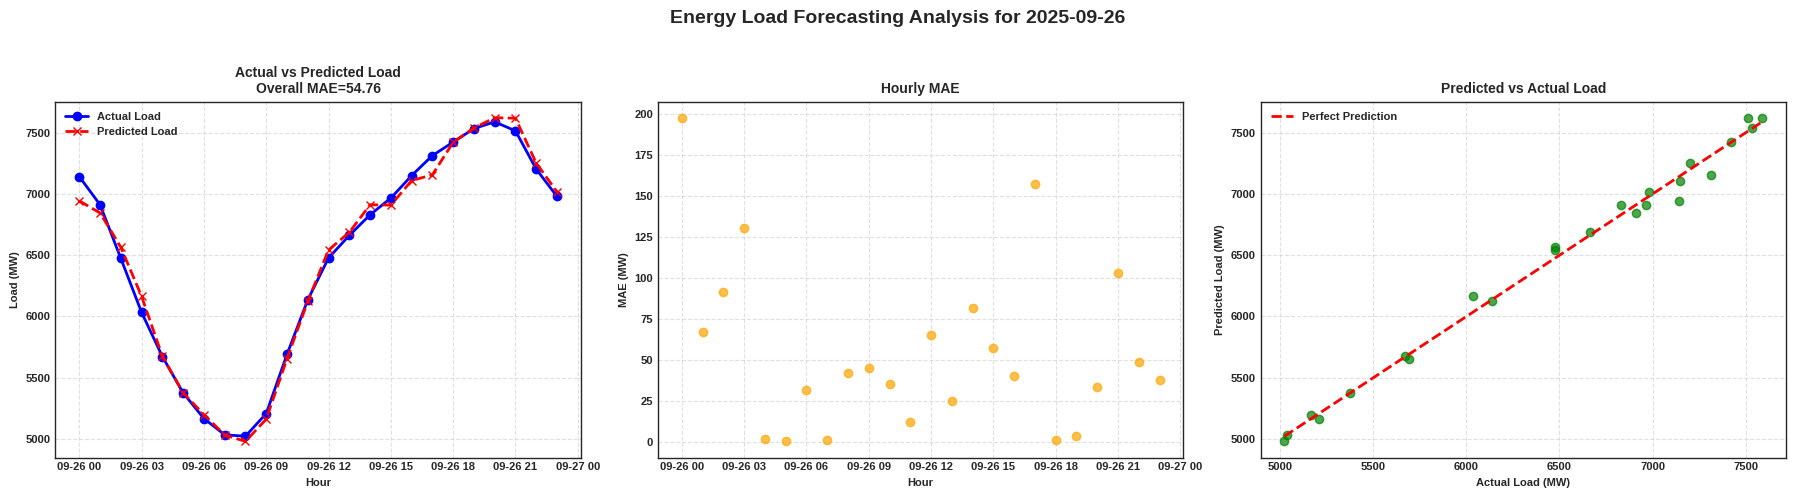

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

test_timestamps = test_df.index[seq_length:]

target_date = "2025-09-26"
mask = (test_timestamps.date == pd.to_datetime(target_date).date())

X_day = X_test_seq[mask]
y_day_true = y_test_seq[mask]
timestamps_day = test_timestamps[mask]

y_day_pred = model.predict(X_day).flatten()


errors = np.abs(y_day_true - y_day_pred)
mae_by_hour = [mean_absolute_error([yt], [yp]) for yt, yp in zip(y_day_true, y_day_pred)]

overall_mae = mean_absolute_error(y_day_true, y_day_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(timestamps_day, y_day_true, label="Actual Load", color="blue", marker="o")
axes[0].plot(timestamps_day, y_day_pred, label="Predicted Load", color="red", linestyle="--", marker="x")
axes[0].set_title(f"Actual vs Predicted Load\nOverall MAE={overall_mae:.2f}", fontsize=10)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Load (MW)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].scatter(timestamps_day, mae_by_hour, color="orange", alpha=0.7)
axes[1].set_title("Hourly MAE", fontsize=10)
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("MAE (MW)")
axes[1].grid(True, linestyle="--", alpha=0.6)

axes[2].scatter(y_day_true, y_day_pred, color="green", alpha=0.7)
axes[2].plot([y_day_true.min(), y_day_true.max()],
             [y_day_true.min(), y_day_true.max()],
             color="red", linestyle="--", label="Perfect Prediction")
axes[2].set_title("Predicted vs Actual Load", fontsize=10)
axes[2].set_xlabel("Actual Load (MW)")
axes[2].set_ylabel("Predicted Load (MW)")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.suptitle(f"Energy Load Forecasting Analysis for {target_date}", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"energy_load_forecasting_{target_date}.png", dpi=300)
plt.show()
